In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (recall_score, confusion_matrix, precision_recall_curve,
                              average_precision_score, f1_score)

# Phase 4 lädt alle Scores aus Artefakten von NB02 und NB03.
# Voraussetzung: NB02 und NB03 vollständig ausgeführt,
# docs/metric_test_scores.csv und docs/log_test_scores.csv vorhanden.
print("Phase 4 — Fusion und Ablation")
print("Lade eingefrorene Test-Scores aus NB02 und NB03.")

Phase 4 — Fusion und Ablation
Lade eingefrorene Test-Scores aus NB02 und NB03.


In [2]:
# ─── Eingefrorene Test-Scores laden (aus NB02) ───────────────────────────────
# Kein Modell-Retrain in Phase 4. Alle Scores stammen aus den Artefakten
# von NB02 (metric_test_scores.csv) und NB03 (log_test_scores.csv).
docs_path = os.path.join(os.getcwd(), "..", "docs")
metric_scores = pd.read_csv(os.path.join(docs_path, "metric_test_scores.csv"))
log_scores    = pd.read_csv(os.path.join(docs_path, "log_test_scores.csv"))
split_df      = pd.read_csv(os.path.join(docs_path, "split_assignments.csv"))

# Sicherheitsprüfung: NB04 darf nur Test-Cases verwenden
test_case_ids = set(split_df[split_df['split'] == 'test']['case_id'])
assert metric_scores['case_id'].isin(test_case_ids).all(), \
    "metric_test_scores.csv enthält Nicht-Test-Cases!"
assert log_scores['case_id'].isin(test_case_ids).all(), \
    "log_test_scores.csv enthält Nicht-Test-Cases!"

# Threshold aus NB02 (val-basiert) auslesen
threshold_p2 = metric_scores['threshold_metric_val'].iloc[0]

# Metrische Scores auf Case-Ebene aggregieren: max_proba pro case_id (max-Aggregation)
case_metric = (metric_scores
               .groupby('case_id')
               .agg(
                   max_proba=('metric_score', 'max'),
                   label=('label', 'max'),
                   dataset_type=('dataset_type', 'first'),
                   scenario_id=('scenario_id', 'first')
               )
               .reset_index())

case_metric['metric_trigger'] = (case_metric['max_proba'] >= threshold_p2).astype(int)

print(f"Threshold P2 (Val-basiert, aus NB02): {threshold_p2:.4f}")
print(f"Cases im Test:                        {len(case_metric)}")
print(f"metric_trigger=1:                     {case_metric['metric_trigger'].sum()}")
print(f"metric_trigger=0 (neg):               {(case_metric['metric_trigger'] == 0).sum()}")

Threshold P2 (Val-basiert, aus NB02): 0.0903
Cases im Test:                        253
metric_trigger=1:                     252
metric_trigger=0 (neg):               1


In [3]:
# ─── Log-Test-Scores laden und Fusion-DataFrame aufbauen ──────────────────────
# Threshold aus NB03 (val-basiert) auslesen
threshold_log = log_scores['threshold_log_val'].iloc[0]

# Sicherheitsprüfung: case_ids aus beiden Artefakten müssen übereinstimmen
assert set(case_metric['case_id']) == set(log_scores['case_id']), \
    "case_id-Mismatch zwischen metric_test_scores und log_test_scores!"

# Fusion-DataFrame: case_metric + log_scores zusammenführen
fusion = case_metric.merge(
    log_scores[['case_id', 'log_score']].rename(columns={'log_score': 'proba_log'}),
    on='case_id', how='inner'
)
# log_trigger aus val-basiertem Threshold berechnen
fusion['log_trigger'] = (fusion['proba_log'] >= threshold_log).astype(int)

assert len(fusion) == len(case_metric) == len(log_scores), \
    f"Case-Mismatch bei Fusion: {len(fusion)} / {len(case_metric)} / {len(log_scores)}"

print(f"Threshold Log (Val-basiert, aus NB03): {threshold_log:.4f}")
print(f"Fusion Cases:                          {len(fusion)}")
print(f"log_trigger=1:                         {fusion['log_trigger'].sum()}")
print(f"log_trigger=0:                         {(fusion['log_trigger'] == 0).sum()}")

Threshold Log (Val-basiert, aus NB03): 0.2300
Fusion Cases:                          253
log_trigger=1:                         90
log_trigger=0:                         163


In [4]:
# fusion bereits in Cell 2 aufgebaut (case_metric + log_scores → fusion)
print(f"Fusion Cases: {len(fusion)} — Alignment OK")

# AND-Gate: Alert nur wenn metric_trigger=1 UND log_trigger=1
fusion['alert'] = ((fusion['metric_trigger'] == 1) & (fusion['log_trigger'] == 1)).astype(int)

# Soft Score für PR-Kurve: Produkt beider Wahrscheinlichkeiten
fusion['score_fusion'] = fusion['max_proba'] * fusion['proba_log']

fusion.to_csv(os.path.join(docs_path, "fusion_cases.csv"), index=False)

y_true  = fusion['label']
y_pred  = fusion['alert']
y_score = fusion['score_fusion']

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
precision_at_t = tp / (tp + fp) if (tp + fp) > 0 else 0
ap_fusion = average_precision_score(y_true, y_score)

print(f"\n=== Phase 4: AND-Fusion Ergebnisse ===")
print(f"AP (soft score):         {ap_fusion:.4f}")
print(f"Recall:                  {recall_score(y_true, y_pred):.4f}")
print(f"Precision @ threshold:   {precision_at_t:.4f}")
print(f"F1:                      {f1_score(y_true, y_pred):.4f}")
print(f"FPR gesamt:              {fp / (fp + tn):.4f}  ({fp} FP von {fp+tn})")

Fusion Cases: 253 — Alignment OK

=== Phase 4: AND-Fusion Ergebnisse ===
AP (soft score):         0.5724
Recall:                  0.9375
Precision @ threshold:   0.5000
F1:                      0.6522
FPR gesamt:              0.2195  (45 FP von 205)


In [5]:
# FPR getrennt nach anom und norm — prüft ob AND-Fusion zwischen
# technischen Anomalien (anom) und täuschend normalen Szenarien (norm) unterscheidet
for dtype in ['anom', 'norm']:
    mask = (fusion['dataset_type'] == dtype).values
    fp_sub = fusion['alert'][mask].sum()
    total_neg = (fusion['label'][mask] == 0).sum()
    print(f"FPR {dtype}: {fp_sub/total_neg:.4f}  ({fp_sub} FP von {total_neg})")

FPR anom: 0.1842  (14 FP von 76)
FPR norm: 0.2403  (31 FP von 129)


In [6]:
# Latenz-Referenz (Messung in NB02 und NB03 — dort direkt nach Modell-Inferenz)
# NB04 misst keine Inferenz-Latenz, da Modelle nicht in dieser Phase retrained werden.
# Die Latenzwerte aus den individuellen Notebooks:
#   NB02 (XGBoost): siehe Cell 5 Output — Latenz predict_proba (indikativ)
#   NB03 (LogReg):  siehe Cell 5 Output — Latenz predict_proba (indikativ)
#   P4 Fusion (P2+P3 sequentiell): Summe beider Einzellatenzen
print("Latenz-Messung in NB02 (XGBoost) und NB03 (LogReg) durchführen.")
print("P4 Fusion Latenz = P2-Latenz + P3-Latenz (sequentiell, indikativ).")

Latenz-Messung in NB02 (XGBoost) und NB03 (LogReg) durchführen.
P4 Fusion Latenz = P2-Latenz + P3-Latenz (sequentiell, indikativ).


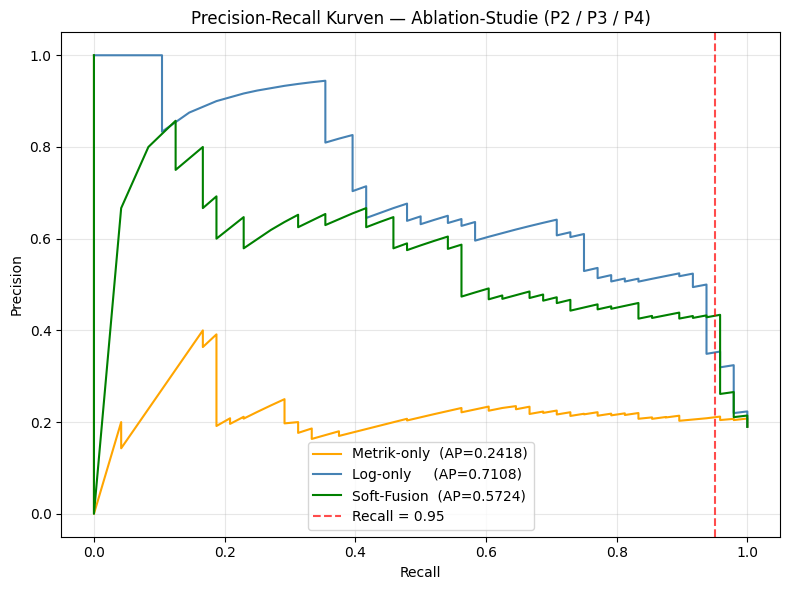

Gespeichert: pr_curve_ablation.png


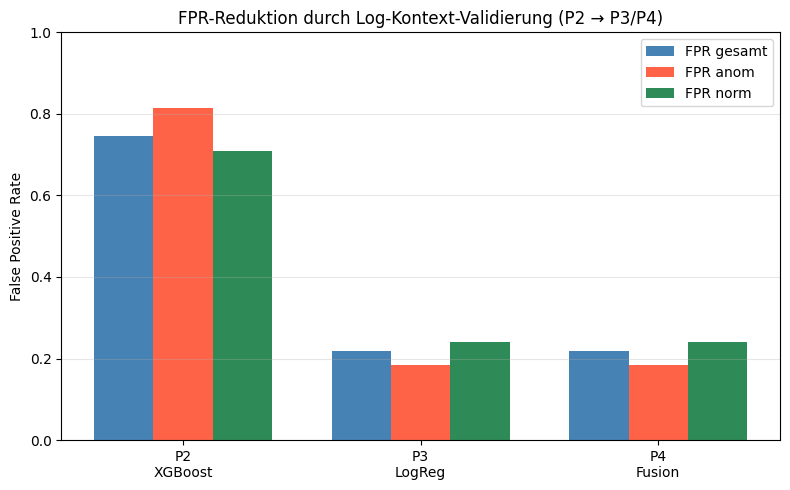

Gespeichert: fpr_comparison.png


In [7]:
plots_path = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(plots_path, exist_ok=True)

# --- Plot 1: Ablation — PR-Kurven aller drei Systeme ---
prec_m, rec_m, _ = precision_recall_curve(fusion['label'], fusion['max_proba'])
prec_l, rec_l, _ = precision_recall_curve(fusion['label'], fusion['proba_log'])
prec_h, rec_h, _ = precision_recall_curve(fusion['label'], fusion['score_fusion'])

ap_m = average_precision_score(fusion['label'], fusion['max_proba'])
ap_l = average_precision_score(fusion['label'], fusion['proba_log'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_m, prec_m, label=f'Metrik-only  (AP={ap_m:.4f})', color='orange')
ax.plot(rec_l, prec_l, label=f'Log-only     (AP={ap_l:.4f})', color='steelblue')
ax.plot(rec_h, prec_h, label=f'Soft-Fusion  (AP={ap_fusion:.4f})', color='green')
ax.axvline(x=0.95, color='red', linestyle='--', alpha=0.7, label='Recall = 0.95')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Kurven — Ablation-Studie (P2 / P3 / P4)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, "pr_curve_ablation.png"), dpi=150)
plt.show()
print("Gespeichert: pr_curve_ablation.png")

# --- Plot 2: FPR-Vergleich P2 / P3 / P4 — dynamisch aus Artefakten ---
# P2: Zeilenebene (metric_test_scores.csv), P3/P4: Case-Ebene
def _fpr(df, pred_col, dtype=None):
    """FPR = FP/(FP+TN) auf negativen Cases (label==0)."""
    sub = df[df['label'] == 0]
    if dtype:
        sub = sub[sub['dataset_type'] == dtype]
    return sub[pred_col].sum() / len(sub) if len(sub) > 0 else 0.0

phases  = ['P2\nXGBoost', 'P3\nLogReg', 'P4\nFusion']
fpr_all  = [_fpr(metric_scores, 'metric_pred'),
            _fpr(log_scores,    'log_pred'),
            _fpr(fusion,        'alert')]
fpr_anom = [_fpr(metric_scores, 'metric_pred', 'anom'),
            _fpr(log_scores,    'log_pred',    'anom'),
            _fpr(fusion,        'alert',       'anom')]
fpr_norm = [_fpr(metric_scores, 'metric_pred', 'norm'),
            _fpr(log_scores,    'log_pred',    'norm'),
            _fpr(fusion,        'alert',       'norm')]

x = np.arange(len(phases)); w = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, fpr_all,  w, label='FPR gesamt', color='steelblue')
ax.bar(x,     fpr_anom, w, label='FPR anom',   color='tomato')
ax.bar(x + w, fpr_norm, w, label='FPR norm',   color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(phases)
ax.set_ylabel('False Positive Rate'); ax.set_ylim(0, 1.0)
ax.set_title('FPR-Reduktion durch Log-Kontext-Validierung (P2 → P3/P4)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, "fpr_comparison.png"), dpi=150)
plt.show()
print("Gespeichert: fpr_comparison.png")